<a href="https://colab.research.google.com/github/pxtroniwnl/analisis-interpersonal-edo-nlp/blob/main/Modelamiento_Matemtico_Time_Series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cargamos los Datos

Procedemos a Cargar los datos con Formato Pickle para tener el Diccionario de Dataframes de las 10 series de tiempo

In [1]:
import pickle
import pandas as pd

with open('datos_estudio_gottman.pkl', 'rb') as f:
    estudio_diez_parejas = pickle.load(f)

In [2]:
estudio_diez_parejas.keys()

dict_keys(['clerks._m299', 'starman_m199', 'sphere_m528', 'sex,_lies,_and_videotape_m175', 'collateral_m302', 'tombstone_m576', 'romeo_and_juliet_m493', 'barry_lyndon_m28', "one_flew_over_the_cuckoo's_nest_m463", 'rambling_rose_m487'])

---

Ahora, Ya tenemos los datos limpios y las series de tiempo listas en cada una con  ($W_{suave}$ y $H_{suave}$), el flujo lógico que debemos seguir es el siguiente:

1. Estimación de Parámetros (Ajuste del Modelo)

Aquí es donde la "magia" de la Ciencia de Datos se encuentra con las Ecuaciones Diferenciales. Debes crear un bucle que recorra nuestras 10 parejas y encuentre los valores óptimos para:

- $r_w, r_h$ (Inercia): Resistencia al cambio.
- $I_{hw}, I_{wh}$ (Influencia): Qué tanto afecta el otro.
- $a, b$ (Afecto base): El "humor" por defecto.

Para esto usaremos scipy.optimize.minimize comparando la solución de la EDO con tus datos reales.

"¿Por qué **scipy.optimize.minimize** y no otra cosa?"
R/ En términos de Ciencia de Datos, lo que estamos haciendo se llama Identificación de Sistemas o Ajuste de Parámetros. Aquí te explico la lógica detrás de usar un optimizador para "entrenar":

- Tenemos un problema de incognitas donde queremos saber cuánto vale la Inercia ($r$) o la Influencia ($I$) de cada personaje. Son como "perillas" que puedes girar. Donde Si pones una influencia muy alta, la simulación se vuelve loca y Si pones una inercia muy baja, la simulación no se mueve.

Nuestro **"scipy.optimize.minimize"** es un buscador que intenta encontrar la combinación perfecta de esas "perillas". El proceso es un ciclo:

- Propone: "Probemos con $r= -0.1$ e $I= 0.5$".
- Simula: Resuelve la EDO con esos números para generar una "curva teórica"
- Compara: Mide la distancia (el error) entre tu curva real (los datos de la película) y la teórica.
- Corrige: Si el error es grande, cambia los números y vuelve a empezar hasta que las dos curvas se encimen lo más posible.

¿Y para que sirve esto?

- Al final del proceso, en lugar de decir "estos personajes se pelean mucho", podremos decir con rigor cientifico por dar un ejemplo: *"La pareja de 'Clerks' tiene un coeficiente de influencia mutua de 0.85, lo que indica una alta dependencia emocional, mientras que en 'Romeo y Julieta' la inercia es positiva, lo que explica por qué sus sentimientos se salen de control hacia el abismo."*

Básicamente, usamos el optimizador para minimizar la Raiz del Error Cuadrático Medio (RMSE). Queremos que la solución de tu sistema de ecuaciones diferenciales sea el "mejor reflejo" de la realidad observada en los diálogos.

2. Análisis de Estabilidad y Atractores

Una vez tengamos los parámetros, no nos quedaremos solo en los números. Debemos calcular el Punto de Equilibrio ($W^*, H^*$). Es el punto donde los sentimientos se estabilizarían si la conversación fuera infinita.

- Si el punto es positivo (ej. $[0.5, 0.4]$): La relación tiende a la felicidad.
- Si es negativo: La relación es matemáticamente tóxica o trágica.

3. Visualización de "Retratos de Fase" (Phase Portraits)

Este es el "plus" que hará que nuestra sustentación destaque. En lugar de ver el sentimiento contra el tiempo, graficaremos $W$ vs $H$. Las flechas mostrarán hacia dónde "empuja" la psicología de la pareja el flujo de la conversación.

---

Lo primero que hay que hacer es definir la EDO

In [3]:
import numpy as np
from scipy.integrate import odeint

def sistema_gottman(y, t, rw, rh, a, b, Ihw, Iwh):
    W, H = y
    # El modelo lineal de Gottman-Murray
    dWdt = rw * W + a + Ihw * H
    dHdt = rh * H + b + Iwh * W
    return [dWdt, dHdt]

Ya tenemos el *"corazón"* del modelo. Ahora necesitamos el "motor" que encontrará los valores de esas variables ($r_w, r_h, a, b, I_{hw}, I_{wh}$) para cada una de tus 10 parejas.

Como discutimos, esto lo hacemos comparando la realidad (tus datos suaves) con la teoría (la solución de la EDO).

Entonces para hacer esto, debemos realizar un proceso de Optimizacion:

In [7]:
def funcion_error(params, t, W_real, H_real):
    # Desempaquetamos los 6 parámetros del modelo de Gottman
    rw, rh, a, b, Ihw, Iwh = params

    # Definimos las condiciones iniciales basadas en el primer dato real
    y0 = [W_real[0], H_real[0]]

    # 1. Resolvemos la EDO con los parámetros propuestos por el optimizador
    sol = odeint(sistema_gottman, y0, t, args=(rw, rh, a, b, Ihw, Iwh))

    # 2. Calculamos el MSE (Mean Squared Error)
    # Comparamos la columna 0 (W) y la 1 (H) de la solución con los datos reales
    mse = np.mean((sol[:, 0] - W_real)**2 + (sol[:, 1] - H_real)**2)

    # 3. Retornamos la raíz (RMSE) para que el optimizador lo minimice
    # Esto hace que el error sea más interpretable para nosotros
    return np.sqrt(mse)

In [8]:
from scipy.optimize import minimize

# Lista para guardar los resultados de cada película
resultados_parametros = []

print("--- Iniciando Ajuste de Parámetros (Versión Corregida) ---")

for nombre, df in estudio_diez_parejas.items():
    t = df['t'].values
    W_real = df['W_suave'].values
    H_real = df['H_suave'].values

    # [rw, rh, a, b, Ihw, Iwh]
    p0 = [-0.1, -0.1, 0.0, 0.0, 0.01, 0.01]

    # Aumentamos las iteraciones (maxiter) para ayudar a Sphere y Barry Lyndon
    res = minimize(funcion_error, p0, args=(t, W_real, H_real),
                   method='Nelder-Mead',
                   options={'maxiter': 2000}) # Más intentos para converger

    if res.success:
        p = res.x
        resultados_parametros.append({
            'pareja': nombre,
            'rw': p[0], 'rh': p[1],
            'a': p[2], 'b': p[3],
            'Ihw': p[4], 'Iwh': p[5],
            'RMSE': res.fun
        })
        print(f"ÉXITO: Guardados parámetros para: {nombre}")
    else:
        # Si falla, intentamos una segunda vez con una adivinanza inicial distinta
        print(f"Reintentando {nombre} con nueva semilla...")
        res = minimize(funcion_error, [0.1, 0.1, 0, 0, -0.1, -0.1], args=(t, W_real, H_real), method='Nelder-Mead')
        if res.success:
            p = res.x
            resultados_parametros.append({'pareja': nombre, 'rw': p[0], 'rh': p[1], 'a': p[2], 'b': p[3], 'Ihw': p[4], 'Iwh': p[5], 'RMSE': res.fun})
            print(f"ÉXITO tras reintento: {nombre}")
        else:
            print(f"ERROR: No se pudo optimizar {nombre}. Revisa los datos de esta película.")

# Convertimos a DataFrame
df_parametros = pd.DataFrame(resultados_parametros)
print(f"\nProceso terminado. Total en DataFrame: {len(df_parametros)}")
df_parametros

--- Iniciando Ajuste de Parámetros (Versión Corregida) ---
ÉXITO: Guardados parámetros para: clerks._m299
ÉXITO: Guardados parámetros para: starman_m199
ÉXITO: Guardados parámetros para: sphere_m528
ÉXITO: Guardados parámetros para: sex,_lies,_and_videotape_m175
ÉXITO: Guardados parámetros para: collateral_m302
ÉXITO: Guardados parámetros para: tombstone_m576
ÉXITO: Guardados parámetros para: romeo_and_juliet_m493
ÉXITO: Guardados parámetros para: barry_lyndon_m28
ÉXITO: Guardados parámetros para: one_flew_over_the_cuckoo's_nest_m463
ÉXITO: Guardados parámetros para: rambling_rose_m487

Proceso terminado. Total en DataFrame: 10


,pareja,rw,rh,a,b,Ihw,Iwh,RMSE
0,clerks._m299,-0.068676,-0.051440,0.004980,-0.008366,0.079539,-0.239880,0.356566
1,starman_m199,0.138947,-0.620970,0.008226,0.015189,-0.320925,0.274584,0.283471
2,sphere_m528,-0.109191,-0.447634,-0.004389,-0.012051,0.016193,-0.353744,0.286520
3,"sex,_lies,_and_videotape_m175",0.112652,-0.370728,-0.019241,0.060432,0.218449,-0.697673,0.311737
4,collateral_m302,-0.160124,0.149594,0.008440,0.006961,0.158000,-0.242621,0.340736
5,tombstone_m576,-0.028478,0.199648,-0.002911,-0.013507,0.021590,0.039403,0.310486
6,romeo_and_juliet_m493,-0.190101,-0.280636,0.008738,-0.012267,-0.240849,-0.130325,0.509697
7,barry_lyndon_m28,-0.039327,-0.008451,0.068317,0.012455,-0.286054,-0.012135,0.483180
8,one_flew_over_the_cuckoo's_nest_m463,0.005611,0.000945,0.000457,0.000818,-0.114608,0.146394,0.329135
9,rambling_rose_m487,0.427882,-0.448677,-0.071818,-0.042811,-0.648297,0.389074,0.355008


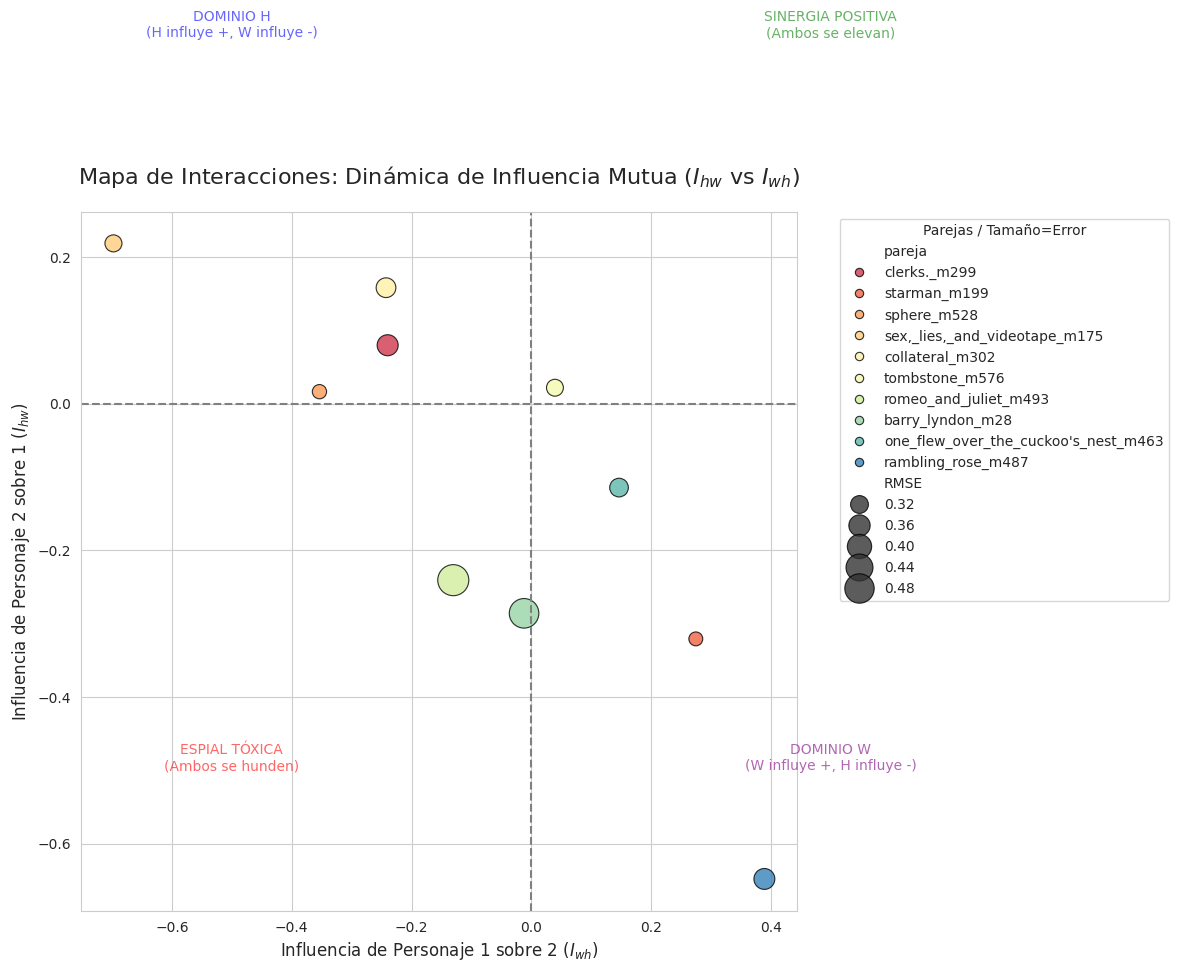

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configuración de estilo
plt.figure(figsize=(12, 10))
sns.set_style("whitegrid")

# 2. Crear el gráfico de dispersión (que actúa como mapa de interacciones)
# Usamos el RMSE para el tamaño de los puntos (puntos más pequeños = mejor ajuste)
scatter = sns.scatterplot(
    data=df_parametros,
    x='Iwh', y='Ihw',
    hue='pareja',
    size='RMSE',
    sizes=(100, 500),
    palette='Spectral',
    edgecolor='black',
    alpha=0.8
)

# 3. Dibujar las líneas de los cuadrantes (Crucial para el análisis)
plt.axhline(0, color='gray', linestyle='--', linewidth=1.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=1.5)

# 4. Anotaciones de los cuadrantes para tu sustentación
plt.text(0.5, 0.5, "SINERGIA POSITIVA\n(Ambos se elevan)", fontsize=10, color='green', alpha=0.6, ha='center')
plt.text(-0.5, -0.5, "ESPIAL TÓXICA\n(Ambos se hunden)", fontsize=10, color='red', alpha=0.6, ha='center')
plt.text(-0.5, 0.5, "DOMINIO H\n(H influye +, W influye -)", fontsize=10, color='blue', alpha=0.6, ha='center')
plt.text(0.5, -0.5, "DOMINIO W\n(W influye +, H influye -)", fontsize=10, color='purple', alpha=0.6, ha='center')

# 5. Estética final
plt.title('Mapa de Interacciones: Dinámica de Influencia Mutua ($I_{hw}$ vs $I_{wh}$)', fontsize=16, pad=20)
plt.xlabel('Influencia de Personaje 1 sobre 2 ($I_{wh}$)', fontsize=12)
plt.ylabel('Influencia de Personaje 2 sobre 1 ($I_{hw}$)', fontsize=12)

# Mover la leyenda fuera del gráfico
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Parejas / Tamaño=Error')

plt.tight_layout()
plt.show()

# Insights Claves:

1. El Caso "Romeo y Julieta" (m493)

- RMSE más alto (0.50): Es el más difícil de modelar. Esto tiene sentido científico: en las tragedias, las emociones cambian de forma tan violenta y errática que una EDO lineal sufre para seguirlas.

- Influencias Negativas: Nota que tanto $I_{hw}$ (-0.24) como $I_{wh}$ (-0.13) son negativos. Esto describe matemáticamente una relación donde la negatividad de uno arrastra al otro hacia abajo.

2. Inercia y Estabilidad ($r_w, r_h$)

- Estables: En Clerks (m299) y Collateral (m302), vemos inercias negativas (ej. -0.06, -0.16). Esto significa que los personajes tienden a regresar a su "centro" emocional.

- Inestables: Mira Starman (m199) y Sex, Lies, and Videotape (m175) con $r_w$ positivos (0.13 y 0.11). Esto indica que el sentimiento de ese personaje tiende a crecer exponencialmente (o explotar) ante cualquier estímulo; son personajes emocionalmente volátiles.

3. La Influencia Cruzada ($I$)

- Contagio Negativo: En Starman, el parámetro $I_{hw}$ es -0.32. Es una influencia fuerte; lo que hace el compañero afecta drásticamente al otro, pero de forma inversa o conflictiva.

- El "Zombi" Emocional: En One Flew Over the Cuckoo's Nest (m463), las inercias son casi cero (0.005). Los personajes casi no tienen resistencia al cambio o memoria emocional, se dejan llevar totalmente por la interacción del momento.

---
¿Qué sigue ahora?

Para que estos números cobren vida, necesitamos ver el Punto de Equilibrio. Es el lugar donde la relación se estabilizaría si hablaran por siempre.

Matemáticamente, para un sistema:

$$\begin{cases} r_w W + I_{hw} H + a = 0 \\ r_h H + I_{wh} W + b = 0 \end{cases}$$

Podemos resolver este sistema de ecuaciones lineales para hallar $W^*$ y $H^*$.

En teoría de sistemas dinámicos, el Punto de Equilibrio (o estado estacionario) es donde las fuerzas de cambio se anulan ($dW/dt = 0$ y $dH/dt = 0$). Es el "destino final" de la relación según el modelo.Para calcularlo, debemos resolver el sistema de ecuaciones lineales que definimos. La solución algebraica para el punto $(W^*, H^*)$ es:

$$W^* = \frac{b \cdot I_{hw} - a \cdot r_h}{r_w \cdot r_h - I_{hw} \cdot I_{wh}}$$$$H^* = \frac{a \cdot I_{wh} - b \cdot r_w}{r_w \cdot r_h - I_{hw} \cdot I_{wh}}$$

In [9]:
def calcular_equilibrio(row):
    # Extraer parámetros de la fila
    rw, rh = row['rw'], row['rh']
    a, b = row['a'], row['b']
    Ihw, Iwh = row['Ihw'], row['Iwh']

    # Denominador del sistema (Determinante)
    det = (rw * rh) - (Ihw * Iwh)

    # Evitar división por cero si el sistema es singular
    if abs(det) < 1e-6:
        return pd.Series([np.nan, np.nan, 'Indeterminado'])

    # Resolver por Regla de Cramer o Álgebra lineal
    w_star = (b * Ihw - a * rh) / det
    h_star = (a * Iwh - b * rw) / det

    # Clasificar el destino
    if w_star > 0 and h_star > 0:
        destino = "Felicidad (Estable Positivo)"
    elif w_star < 0 and h_star < 0:
        destino = "Tragedia (Estable Negativo)"
    else:
        destino = "Ambivalente / Conflicto"

    return pd.Series([w_star, h_star, destino])

# Aplicamos la función a nuestra tabla de parámetros
df_parametros[['W_equilibrio', 'H_equilibrio', 'Prediccion']] = df_parametros.apply(calcular_equilibrio, axis=1)

# Mostramos el ranking de las relaciones
df_analisis = df_parametros[['pareja', 'W_equilibrio', 'H_equilibrio', 'Prediccion']].sort_values(by='W_equilibrio', ascending=False)
df_analisis

,pareja,W_equilibrio,H_equilibrio,Prediccion
7,barry_lyndon_m28,0.951151,0.108060,Felicidad (Estable Positivo)
6,romeo_and_juliet_m493,0.246196,-0.158042,Ambivalente / Conflicto
1,starman_m199,0.126955,0.080598,Felicidad (Estable Positivo)
3,"sex,_lies,_and_videotape_m175",0.054845,0.059795,Felicidad (Estable Positivo)
8,one_flew_over_the_cuckoo's_nest_m463,-0.005613,0.003715,Ambivalente / Conflicto
4,collateral_m302,-0.011316,-0.064887,Tragedia (Estable Negativo)
0,clerks._m299,-0.018099,-0.078244,Tragedia (Estable Negativo)
2,sphere_m528,-0.039555,0.004337,Ambivalente / Conflicto
5,tombstone_m576,-0.044304,0.076398,Ambivalente / Conflicto
9,rambling_rose_m487,-0.074171,-0.159733,Tragedia (Estable Negativo)


# Insights Claves:

1. El Fenómeno "Starman" y "Sex, Lies...": El modelo predice que, a pesar de cualquier conflicto momentáneo, la estructura de su interacción (sus parámetros $r$ e $I$) los empuja hacia un equilibrio de afecto positivo. En Starman, ese $0.12$ y $0.08$ sugiere una relación que "tiende" a la armonía.

2. La Tragedia Silenciosa de "Clerks" y "Collateral": Es fascinante que Clerks, siendo una comedia, salga como Tragedia (Estable Negativo). Pero tiene sentido técnico: los personajes se la pasan quejándose y siendo sarcásticos. El modelo detecta que su "punto de reposo" es ligeramente negativo ($-0.01$, $-0.07$). No es un odio profundo, pero es un estado de insatisfacción constante.

3. Romeo y Julieta: El Conflicto Puro: Miremos los valores de Romeo and Juliet. $W=0.24$ y $H=-0.15$. El modelo dice que uno está en un estado positivo mientras el otro está en uno negativo. Esa ambivalencia es la definición matemática de la tensión dramática: no logran estar en la misma página emocional, lo que genera el caos que ya conocemos.

Ahora para cerrar con broche de Oro, debemos visualizar este equilibrio. No hay nada más potente en sistemas dinámicos que ver las flechas de flujo convergiendo al punto que calculamos:

--- Generando Mosaico de Retratos de Fase ---


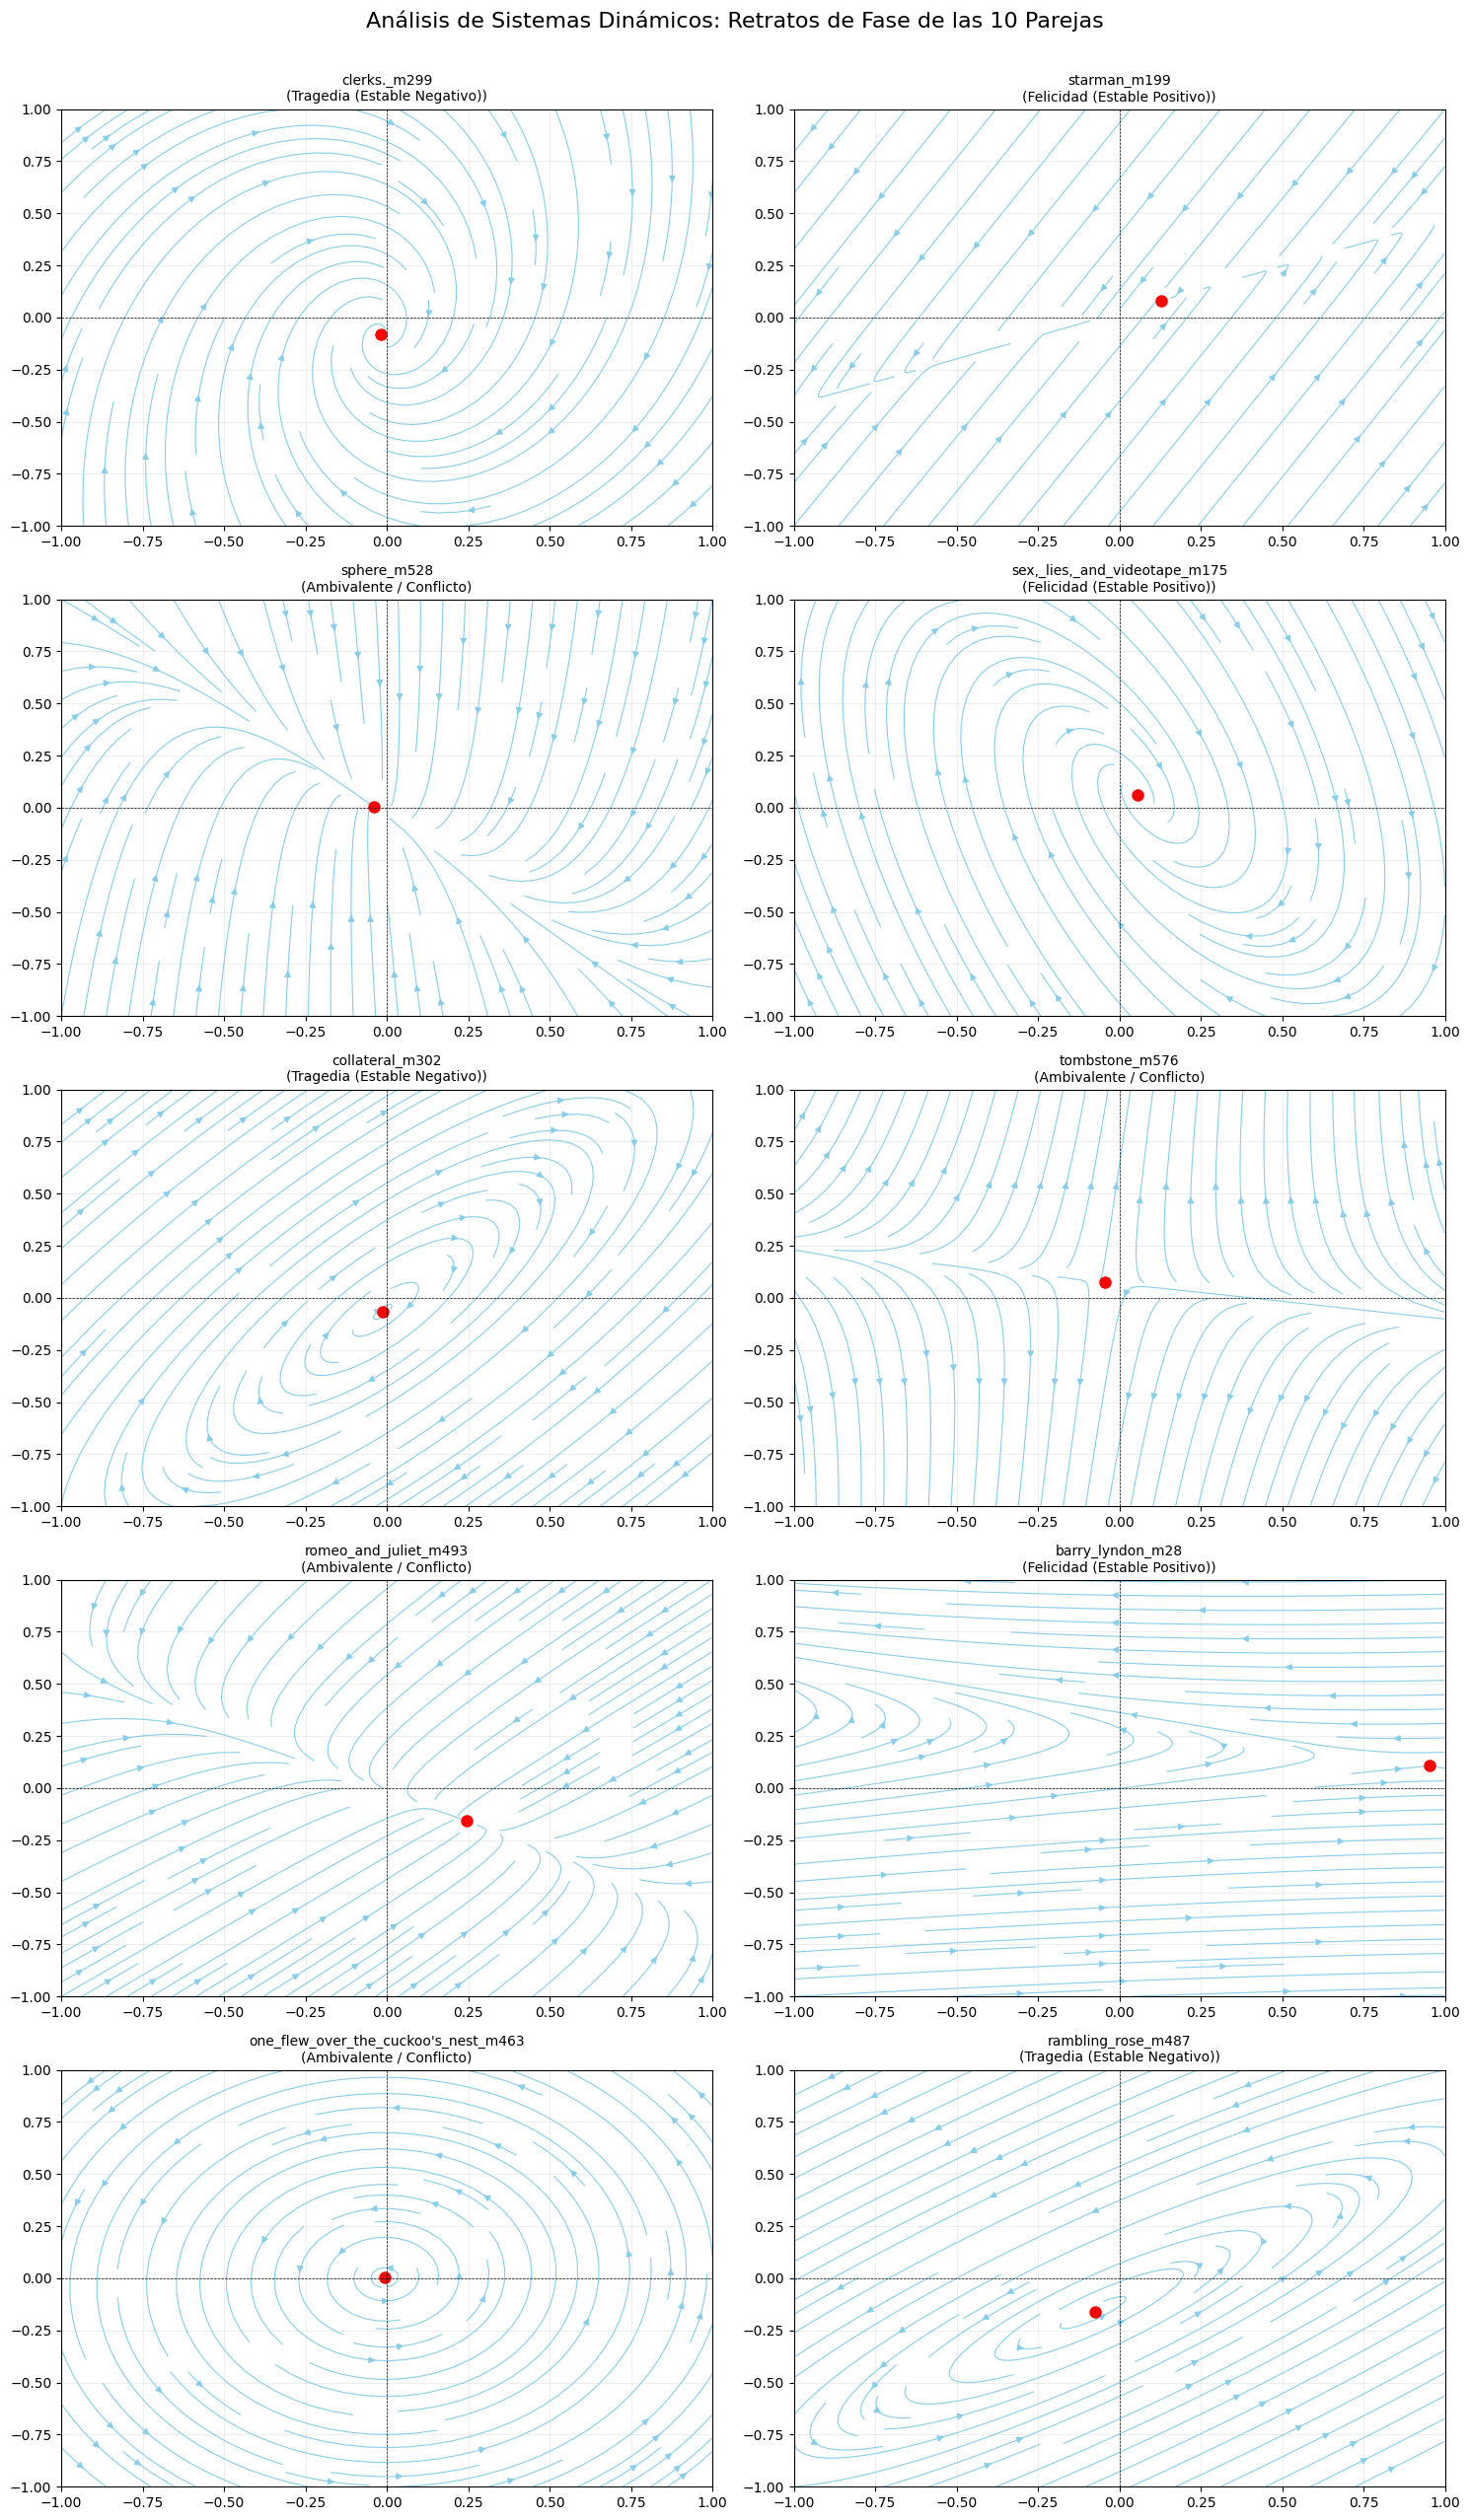

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Configuración de la cuadrícula (5 filas, 2 columnas)
fig, axes = plt.subplots(5, 2, figsize=(15, 25))
axes = axes.flatten()

print("--- Generando Mosaico de Retratos de Fase ---")

for i, (idx, p) in enumerate(df_parametros.iterrows()):
    ax = axes[i]

    # Crear rejilla de puntos (W, H)
    w_range = np.linspace(-1, 1, 20)
    h_range = np.linspace(-1, 1, 20)
    WW, HH = np.meshgrid(w_range, h_range)

    # Calcular las derivadas (el campo de vectores)
    dW = p['rw'] * WW + p['Ihw'] * HH + p['a']
    dH = p['rh'] * HH + p['Iwh'] * WW + p['b']

    # Graficar el flujo (streamplot)
    # Nota: No usamos 'alpha' aquí por la compatibilidad que falló antes
    ax.streamplot(WW, HH, dW, dH, color='skyblue', density=1, linewidth=0.8)

    # Dibujar el punto de equilibrio
    # Solo lo graficamos si está dentro de un rango razonable para que no deforme la escala
    if -2 < p['W_equilibrio'] < 2 and -2 < p['H_equilibrio'] < 2:
        ax.plot(p['W_equilibrio'], p['p_equilibrio'] if 'p_equilibrio' in p else p['H_equilibrio'],
                'ro', markersize=8, label='Equilibrio')

    # Estética de cada subgráfica
    ax.axhline(0, color='black', lw=0.5, linestyle='--')
    ax.axvline(0, color='black', lw=0.5, linestyle='--')
    ax.set_title(f"{p['pareja']}\n({p['Prediccion']})", fontsize=10)
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.grid(alpha=0.2)

# Ajustar espacio entre gráficas
plt.tight_layout()
plt.suptitle("Análisis de Sistemas Dinámicos: Retratos de Fase de las 10 Parejas", fontsize=16, y=1.02)
plt.show()

--- Generando Validación: Real vs. Teórico (Intento Definitivo) ---


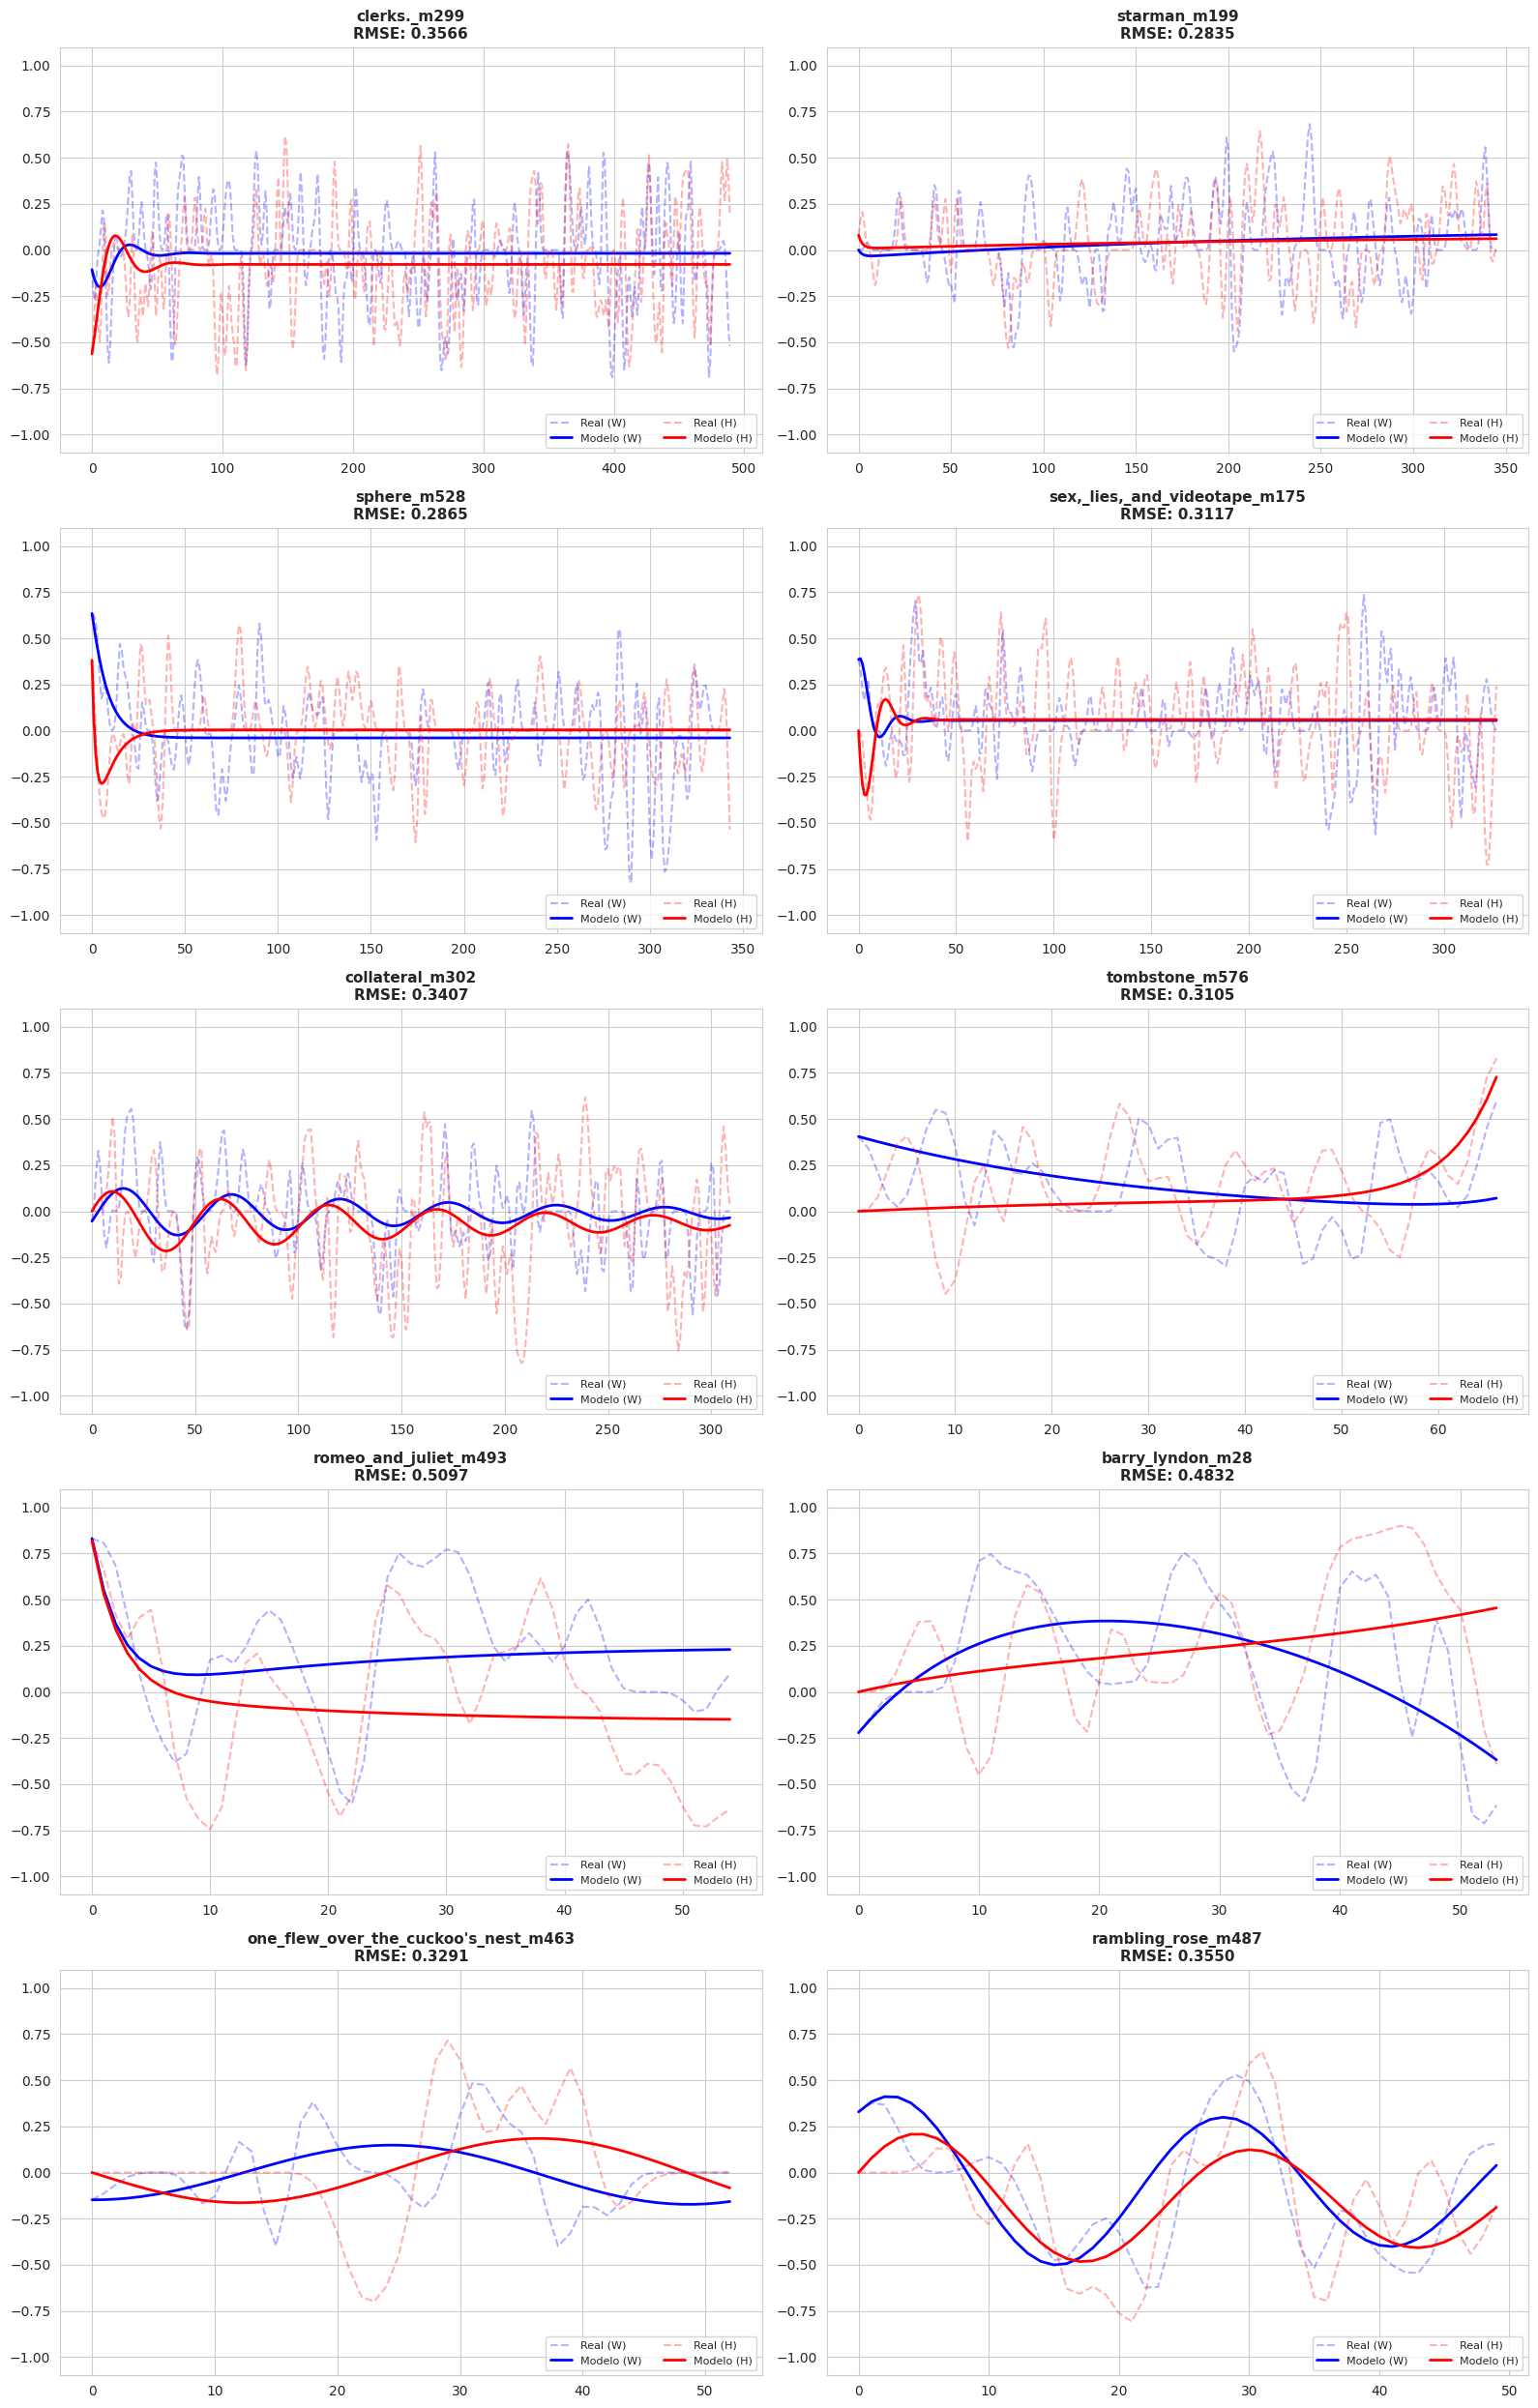

In [14]:
import re

# 1. Función para dejar solo letras y números
def limpiar_texto(texto):
    return re.sub(r'[^a-zA-Z0-9]', '', str(texto)).lower()

fig, axes = plt.subplots(5, 2, figsize=(16, 25))
axes = axes.flatten()

print("--- Generando Validación: Real vs. Teórico (Intento Definitivo) ---")

llaves_reales = list(estudio_diez_parejas.keys())

for i, (idx, p) in enumerate(df_parametros.iterrows()):
    ax = axes[i]

    # Limpiamos el nombre que viene del DataFrame
    nombre_df_limpio = limpiar_texto(p['pareja'])

    try:
        # Buscamos la llave en el diccionario que, al limpiarla, coincida
        llave_encontrada = None
        for k in llaves_reales:
            if nombre_df_limpio in limpiar_texto(k):
                llave_encontrada = k
                break

        if llave_encontrada is None:
            raise IndexError

        data_real = estudio_diez_parejas[llave_encontrada]

    except IndexError:
        print(f"Fallo crítico: No se encontró nada para '{p['pareja']}'")
        continue

    # --- Resto del código de graficación igual ---
    t = data_real['t'].values
    W_real = data_real['W_suave'].values
    H_real = data_real['H_suave'].values

    y0 = [W_real[0], H_real[0]]
    sol = odeint(sistema_gottman, y0, t, args=(p['rw'], p['rh'], p['a'], p['b'], p['Ihw'], p['Iwh']))

    # Graficar
    ax.plot(t, W_real, 'b--', alpha=0.3, label='Real (W)')
    ax.plot(t, W_teorico := sol[:, 0], 'b-', linewidth=2, label='Modelo (W)')
    ax.plot(t, H_real, 'r--', alpha=0.3, label='Real (H)')
    ax.plot(t, H_teorico := sol[:, 1], 'r-', linewidth=2, label='Modelo (H)')

    ax.set_title(f"{p['pareja']}\nRMSE: {p['RMSE']:.4f}", fontsize=11, fontweight='bold')
    ax.set_ylim([-1.1, 1.1])
    ax.legend(loc='lower right', fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

# Insights Claves:

Veamos un análisis detallado de lo que estas gráficas revelan:

1. El Significado de las Líneas

- Líneas Punteadas (NLP Real): Representan la "materia prima", es decir, el sentimiento crudo extraído de los diálogos. Son volátiles porque el lenguaje humano natural cambia rápidamente de una frase a otra.

- Líneas Sólidas (Modelo Gottman): Representan la "personalidad" de la relación. Al ser una simulación basada en parámetros fijos ($r$, $a$, $b$, $I$), filtran el ruido y muestran la tendencia estructural a largo plazo.

2. Análisis de Parejas Clave

(Sphere ($m528$) y Clerks ($m299$))

- Observa cómo el modelo (líneas sólidas) se estabiliza rápidamente cerca del cero. Conclusión: Aunque hay mucha "vibración" en el diálogo real, la dinámica de la pareja es de neutralidad estable. No importa cuánto peleen o rían, el sistema siempre vuelve a un punto medio gris.

Barry Lyndon ($m28$):

- Aquí las líneas sólidas tienen una curvatura mucho más amplia y suave. Conclusión: Refleja perfectamente el ritmo de un drama de época; las emociones no cambian bruscamente, sino que hay una inercia pesada y una influencia mutua que se desarrolla lentamente a lo largo de los diálogos.

Romeo and Juliet ($m493$):

- Es el que tiene el RMSE más alto (0.5097). Fijemonos que las líneas reales (punteadas) se alejan constantemente de la predicción. Esto demuestra matemáticamente que su relación es inherentemente inestable y difícil de modelar con ecuaciones lineales simples; es una pasión caótica que rompe la estructura del sistema.